01 · Abstract graphs (graphs that are not anywhere)

In notebooks 06 to 19 the nodes arrive with coordinates and the drawing is a
measurement: two nodes are far apart on the page because they are far apart on
the ground. An abstract graph is a set of nodes and a set of pairs, nothing
else. Every position below was invented by a layout algorithm, and a different
algorithm or seed invents different ones for the same graph. Hence
**16 · Layouts**.

Here: edge list and adjacency matrix into Blender, and Python values onto the
mesh as attributes, the currency **17 · Centrality**, **18 · Algorithms** and
**19 · Topology** spend. The graphs are NetworkX generators plus one real
sparse matrix from SuiteSparse. No internet needed; section 7 is a switch, off
by default.

## 0 · Setup

In [1]:
import pathlib
import sys


def find_repo():
    """Locate the SciGraphs repository, without relying on the cwd.

    In a normal Jupyter the kernel starts per notebook with the cwd set to its
    folder. Not here: the kernel lives inside Blender and existed before you
    opened anything, so the cwd is wherever Blender was launched from. What the
    extension does know is which folder it is serving to JupyterLab.
    """
    candidates = []
    try:
        import bpy
        prefs = bpy.context.preferences.addons[
            "bl_ext.user_default.jupyter_blender"].preferences
        candidates.append(pathlib.Path(bpy.path.abspath(prefs.notebook_dir)))
    except Exception:
        pass
    candidates.append(pathlib.Path.cwd())

    for base in candidates:
        for directory in (base, *base.parents):
            if (directory / "SciGraphs" / "api" / "graphs.py").is_file():
                return directory

    raise RuntimeError(
        "Cannot find the SciGraphs repository. Point at it by hand:\n"
        "    sys.path.insert(0, '/path/to/SciGraphs-1/notebooks/tools')")


sys.path.insert(0, str(find_repo() / "notebooks" / "tools"))

import bpy
import networkx as nx
import numpy as np
import pandas as pd

# `nb` must import first: it puts this repository on sys.path, so the
# `SciGraphs` import below reads this tree, not the copy Blender installed.
import nb
from nb import check

from SciGraphs import api as sg

# `SEED` goes to the NetworkX generators. `LAYOUT_SEED` goes to NumPy's global
# RNG immediately before each import, which is what the default 2D spring
# layout draws from, not the add-on's own layout RNG (section 2 measures it).
SEED = 42
LAYOUT_SEED = 7

OUT = nb.out("15_abstract")
OUT.mkdir(parents=True, exist_ok=True)

print("networkx", nx.__version__)
print("working directory for this notebook:", nb.rel(OUT))

networkx 3.6
working directory for this notebook: notebooks/out/15_abstract


## 1 · Four graphs, no coordinates

Chosen for what they *disagree* about: a figure that works for one can be a
lie about another.

| Generator | What it models | The property that matters here |
|---|---|---|
| `karate_club_graph()` | a real 1970s social network, 34 people | small enough to read node by node |
| `erdos_renyi_graph(n, p)` | pure chance | degrees cluster around the mean |
| `barabasi_albert_graph(n, m)` | preferential attachment | degrees are heavy-tailed: a few hubs |
| `watts_strogatz_graph(n, k, p)` | a ring with shortcuts | the interesting structure is on the **edges** |

In [2]:
GRAPHS = {
    "karate":  nx.karate_club_graph(),
    "random":  nx.erdos_renyi_graph(300, 0.02, seed=SEED),
    "scale_free": nx.barabasi_albert_graph(300, 2, seed=SEED),
    "small_world": nx.watts_strogatz_graph(240, 6, 0.08, seed=SEED),
}

rows = []
for name, G in GRAPHS.items():
    degrees = np.array([d for _, d in G.degree()], dtype=float)
    rows.append({
                "graph": name,
                "nodes": G.number_of_nodes(),
                "edges": G.number_of_edges(),
                "mean_degree": round(degrees.mean(), 2),
                "max_degree": int(degrees.max()),
                "max/median": round(degrees.max() / max(np.median(degrees), 1.0), 1),
                "components": nx.number_connected_components(G),
                "isolated": len(list(nx.isolates(G))),
                })
print(pd.DataFrame(rows).to_string(index=False))

check("no generator gives its nodes a position",
      all(not any("pos" in d or "x" in d for _, d in G.nodes(data=True))
      for G in GRAPHS.values()),
      "there is nothing in these objects but nodes and pairs")

      graph  nodes  edges  mean_degree  max_degree  max/median  components  isolated
     karate     34     78         4.59          17         5.7           1         0
     random    300    889         5.93          19         3.2           2         1
 scale_free    300    596         3.97          55        18.3           1         0
small_world    240    720         6.00           8         1.3           1         0
[PASS] no generator gives its nodes a position — there is nothing in these objects but nodes and pairs


True

## 2 · Getting one in: the edge list

`bpy.ops.scigraphs.create_graph`, behind the **Create Graph** button, takes no
graph argument; it reads the scene's import settings, which the panel writes
into. Same three steps as the GUI, same order:

1. `scene.scigraphs.filepath`: a CSV (or a `.gexf`). First, and not for
   tidiness: `source_column` and `target_column` are dynamic enums rebuilt
   from the header whenever they are touched
   (`SciGraphs/properties/callbacks.py:21`). With no filepath the only item is
   `'0'`, and assigning anything else raises `TypeError`.
2. `bpy.ops.scigraphs.load_columns()`: reads the header, guesses a type per
   column, fills the *import as attribute* checkboxes section 4 needs, and
   runs the geospatial auto-detection warned about below.
3. `bpy.ops.scigraphs.create_graph()`.

The column properties hold the column's **index as a string**, not its name.

In [3]:
def write_edge_csv(G, path, edge_columns=()):
    """One row per edge: source, target, and one column per callable given.

    `edge_columns` is a sequence of `(name, fn)` where `fn(u, v)` returns a
    number. This is the format `create_graph` expects, and the *only* thing it
    expects: an edge list has no way to say that a node exists. Section 6
    measures what that costs.
    """
    frame = pd.DataFrame(
        [{"source": u, "target": v,
         **{name: fn(u, v) for name, fn in edge_columns}}
         for u, v in G.edges()])
    frame.to_csv(path, index=False)
    return path


def import_edge_list(path, name, auto_layout=True, layout='SPRING',
                     layout_seed=LAYOUT_SEED, directed=False):
    """The three-step operator route, plus the seed the add-on does not set."""
    props = bpy.context.scene.scigraphs
    props.filepath = str(path)                # must precede the two enums
    props.csv_delimiter = ','
    bpy.ops.scigraphs.load_columns()
    props.use_geospatial = False              # see the warning below
    props.source_column = '0'
    props.target_column = '1'
    props.is_directed = directed
    props.remove_self_loops = True
    props.auto_layout_on_import = auto_layout
    props.layout_algorithm = layout
    props.layout_scale = 5.0
    np.random.seed(layout_seed)               # see the note below
    # Read the status, do not rely on an exception. Under `blender -b` an
    # operator error raises `RuntimeError`, but a live session swallows it and
    # returns `{'CANCELLED'}`, so `try`/`except` passes in the harness and
    # silently believes a failed import in front of a reader.
    status = bpy.ops.scigraphs.create_graph()
    if 'FINISHED' not in status:
        raise RuntimeError(f"create_graph returned {set(status)}")
    obj = bpy.context.active_object
    obj.name = name
    return obj


sg.graphs.clear_scene(keep_anchor=False)

karate_csv = write_edge_csv(GRAPHS["karate"], OUT / "karate_edges.csv")
print(pathlib.Path(karate_csv).read_text().splitlines()[:4])

karate = import_edge_list(karate_csv, "Karate")
print()
print(sg.graphs.summary(karate))

['source,target', '0,1', '0,2', '0,3']
Info: Loaded 2 columns
Loading graph from notebooks/out/15_abstract/karate_edges.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 34, Edges: 78

Creating graph object with 34 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  78 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target']
DataFrame shape: (78, 2)
Source column: source, Target column: target
Number of mesh vertices: 34
Number of mesh edges: 78
Selected attributes for import: ['source', 'target']
Imported 0 attribute columns
  Attributes imported in 0.00s
Total graph creation time: 0.00s

Layout algorithm: SPRING
Graph: 34 nodes, 78 edges
Parameters:
  - algorithm: SPRING
  - iterations: 50
  - scale: 5.0000
  - num_nodes: 34
  - num_edges: 78
Execution time: 0.003s
Status: success

Info: Auto-layout applied: SPRING
Info: 

Both the topology and the identifiers have failed to survive
this trip silently before.

In [4]:
def node_names(obj):
    """The graph's node identifiers, in mesh-vertex order.

    SciGraphs stores them as one comma-joined string in a custom property
    (`SciGraphs/core/mesh/geometry.py:383`), so vertex *i* is `names[i]` and
    that is the only way back from a mesh index to a name.
    """
    return obj.get("nodes_data", "").split(",")


def edge_pairs(obj):
    """The (i, j) vertex indices of every mesh edge, in mesh-edge order."""
    flat = np.empty(len(obj.data.edges) * 2, dtype=np.int32)
    obj.data.edges.foreach_get("vertices", flat)
    return flat.reshape(-1, 2)


names = node_names(karate)
imported = {frozenset((int(names[a]), int(names[b]))) for a, b in edge_pairs(karate)}
original = {frozenset(e) for e in GRAPHS["karate"].edges()}

check("every node arrived", len(names) == GRAPHS["karate"].number_of_nodes(),
      f"{len(names)} names, first four {names[:4]}")
check("the edge set is identical", imported == original,
      f"{len(imported)} mesh edges vs {len(original)} in NetworkX")

[PASS] every node arrived — 34 names, first four ['0', '1', '2', '3']
[PASS] the edge set is identical — 78 mesh edges vs 78 in NetworkX


True

> **Defect: `load_columns` can turn an abstract import into a
> geospatial one from the column names alone.** Its last act,
> `scigraphs.detect_geospatial` (`data_operators.py:127`), matches latitude
> and longitude columns by **substring** against
> `['lat', 'latitude', 'y', 'coord_y']` and `['lon', 'long', 'longitude', 'x',
> 'coord_x']` (`SciGraphs/core/geo/geospatial.py:40`). A bare `'y'` matches
> *any* numeric column containing the letter y (`density`, `entropy`,
> `community`, `delay`); `'x'` matches `max_load`, `index`, `flux`. Both
> hitting sets `props.use_geospatial` to `True` for good, and the next
> `create_graph` takes the geospatial branch (`data_operators.py:212`): a
> globe, and with `geocode_columns` defaulting to `True`
> (`properties/scene_properties.py:215`), the identifiers go through Nominatim
> as place names. That is a network call, so the cell below stops at the
> detection. Fix: `use_geospatial = False` *after* `load_columns`, as
> `import_edge_list` does.

In [5]:
trap_csv = OUT / "innocent_column_names.csv"
pd.DataFrame([{"source": u, "target": v, "density": 0.5, "max_load": 2.0}
             for u, v in list(GRAPHS["karate"].edges())[:10]]).to_csv(
             trap_csv, index=False)

props = bpy.context.scene.scigraphs
props.use_geospatial = False
props.filepath = str(trap_csv)
bpy.ops.scigraphs.load_columns()

print(f"columns          : {[i.name for i in props.available_csv_columns]}")
print(f"use_geospatial   : {props.use_geospatial}")
print(f"latitude column  : {props.latitude_column}  "
      f"longitude column: {props.longitude_column}")

check("two ordinary column names switched the importer to globe mode",
      props.use_geospatial,
      "'density' matched the 'y' pattern, 'max_load' matched 'x'")
props.use_geospatial = False

Detected geospatial columns: density, max_load
Info: Detected geospatial columns: density, max_load
Info: Loaded 4 columns
columns          : ['source', 'target', 'density', 'max_load']
use_geospatial   : True
latitude column  : 2  longitude column: 3
[PASS] two ordinary column names switched the importer to globe mode — 'density' matched the 'y' pattern, 'max_load' matched 'x'


> **Defect: node identifiers are a comma-joined string.**
> `nodes_data` and `edges_data` are built with `",".join(...)`
> (`SciGraphs/core/mesh/geometry.py:383` and `:394`) and split back with
> `str.split(",")` (`SciGraphs/core/mesh/layouts/common.py:118`, `:126`). A
> node whose *name* contains a comma shifts every identifier after it. Not for
> long: the layout raises `IndexError` at `common.py:126`, several steps from
> the cause. Integers or bare words are safe; spreadsheet output is not.

In [6]:
comma_csv = OUT / "comma_labels.csv"
pd.DataFrame({"source": ["Smith, J.", "Lee"], "target": ["Lee", "Ng"]}).to_csv(
    comma_csv, index=False)

before = set(bpy.data.objects)

# Layout off, or it reads the identifiers back and dies with `IndexError` from
# `layouts/common.py:126`. That crash is not catchable here: `bpy.ops` hands it
# to `sys.excepthook` and returns `{'CANCELLED'}`, and in a live kernel that
# hook is IPython's, which fails the cell while the surrounding `try` sees
# nothing. Off, the damage can be inspected instead.
comma_obj = import_edge_list(comma_csv, "CommaLabels", auto_layout=False)

print("nodes_data:", comma_obj["nodes_data"])
print("edges_data:", comma_obj["edges_data"])

# A comma in a name becomes two identifiers, so the edge reader, pairing tokens
# two at a time, runs off the end.
tokens = comma_obj["edges_data"].split(",")
print(f"\n{len(tokens)} tokens for {comma_obj['num_edges']} edges, "
      f"{2 * comma_obj['num_edges']} expected")
check("a comma in a node name corrupts the stored identifiers",
      len(tokens) != 2 * comma_obj["num_edges"],
      "quote it out of the CSV, or rename before import; with the "
      "automatic layout on, this same string aborts the import")

for obj in set(bpy.data.objects) - before:
    bpy.data.objects.remove(obj, do_unlink=True)

Info: Loaded 2 columns
Loading graph from notebooks/out/15_abstract/comma_labels.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 3, Edges: 2

Creating graph object with 3 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  2 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target']
DataFrame shape: (2, 2)
Source column: source, Target column: target
Number of mesh vertices: 3
Number of mesh edges: 2
Imported 0 attribute columns
  Attributes imported in 0.00s
Total graph creation time: 0.00s
Info: Graph created: 3 nodes, 2 edges
nodes_data: Lee,Ng,Smith, J.
edges_data: Smith, J.,Lee,Lee,Ng

5 tokens for 2 edges, 4 expected
[PASS] a comma in a node name corrupts the stored identifiers — quote it out of the CSV, or rename before import; with the automatic layout on, this same string aborts the import


### The layout is not part of the graph

With `auto_layout_on_import` on, the default, `create_graph` also ran a layout
and wrote the result into `node_positions`.

> **Defect: the default 2D spring layout is not reproducible.**
> `_spring_layout_2d` calls `nx.spring_layout(...)` with no `seed=`
> (`SciGraphs/core/mesh/layouts/networkx_layouts.py:8`, 3D twin at `:18`), so
> it draws from NumPy's global RNG. The module keeps a seeded generator for
> exactly this, `_reset_layout_rng()` at the top of every `apply_graph_layout`
> (`SciGraphs/core/mesh/layouts/dispatcher.py:22`), and then does not pass it
> in. Two imports of one file give two different drawings. Seeding `np.random`
> immediately before the operator, as `import_edge_list` does, is the
> workaround; `FORCEATLAS2` threads the seeded generator through
> (`layouts/forceatlas.py:41`) and does not need it.

In [7]:
def positions(obj):
    return np.asarray(list(obj["node_positions"]), dtype=float).reshape(-1, 3)


unseeded_a = import_edge_list(karate_csv, "Unseeded_A", layout_seed=None)
unseeded_b = import_edge_list(karate_csv, "Unseeded_B", layout_seed=None)
seeded_a = import_edge_list(karate_csv, "Seeded_A", layout_seed=11)
seeded_b = import_edge_list(karate_csv, "Seeded_B", layout_seed=11)

drift = np.abs(positions(unseeded_a) - positions(unseeded_b)).max()
print(f"unseeded, two runs: largest disagreement {drift:.3f} Blender units "
      f"(the drawing is ~10 across)")
print(f"seeded, two runs  : largest disagreement "
      f"{np.abs(positions(seeded_a) - positions(seeded_b)).max():.3f}")

check("the unseeded layout is not reproducible", drift > 0.1)
check("seeding numpy first makes it reproducible",
      np.allclose(positions(seeded_a), positions(seeded_b)))
check("the topology never depended on the seed",
      {frozenset((int(node_names(seeded_a)[a]), int(node_names(seeded_a)[b])))
      for a, b in edge_pairs(seeded_a)} == original,
      "different pictures, same graph")

for obj in (unseeded_a, unseeded_b, seeded_a, seeded_b):
    bpy.data.objects.remove(obj, do_unlink=True)

Info: Loaded 2 columns
Loading graph from notebooks/out/15_abstract/karate_edges.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 34, Edges: 78

Creating graph object with 34 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  78 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target']
DataFrame shape: (78, 2)
Source column: source, Target column: target
Number of mesh vertices: 34
Number of mesh edges: 78
Selected attributes for import: ['source', 'target']
Imported 0 attribute columns
  Attributes imported in 0.00s
Total graph creation time: 0.00s

Layout algorithm: SPRING
Graph: 34 nodes, 78 edges
Parameters:
  - algorithm: SPRING
  - iterations: 50
  - scale: 5.0000
  - num_nodes: 34
  - num_edges: 78
Execution time: 0.003s
Status: success

Info: Auto-layout applied: SPRING
Info: Graph created: 34 nodes, 78 edges (SPRI

### The first figure

Every figure here is an EEVEE render straight down through an orthographic
camera (`nb.figure`'s default) with `look='ink'`: turbo colormap,
the darkest of the five backdrops. Thin lines and small glyphs on empty space
need a ramp that never passes near the backdrop, and turbo runs from dark blue
to red, the same reason 03 uses it. The ramp always carries a quantity the
notebook computed, here node degree. The camera assumes the drawing is flat;
`SPRING` is planar, and section 5 measures what the three-dimensional default
would cost.

In [8]:
def set_point_attribute(obj, name, values):
    """Write a per-node float onto the mesh as a POINT attribute.

    `values` is indexed the same way as `node_names(obj)`, in vertex order.
    """
    mesh = obj.data
    if name in mesh.attributes:
        mesh.attributes.remove(mesh.attributes[name])
    attr = mesh.attributes.new(name=name, type='FLOAT', domain='POINT')
    attr.data.foreach_set("value", np.asarray(values, dtype=np.float32).tolist())
    return name


degree = {n: float(d) for n, d in GRAPHS["karate"].degree()}
set_point_attribute(karate, "degree",
                    [degree[int(n)] for n in node_names(karate)])

print("attributes on the karate graph:")
for name, domain, dtype in sg.graphs.attributes(karate):
    print(f"  {name:<28} {domain:<7} {dtype}")

check("degree arrived as a POINT attribute",
      sg.render.attribute_domain(karate, "degree") == 'POINT')

attributes on the karate graph:
  node_id                      POINT   INT
  position                     POINT   FLOAT_VECTOR
  .edge_verts                  EDGE    INT32_2D
  .corner_vert                 CORNER  INT
  .corner_edge                 CORNER  INT
  degree                       POINT   FLOAT
[PASS] degree arrived as a POINT attribute


True

**Node size is not left alone.** `render_eevee` derives the
glyph radius from the graph, the median nearest-neighbor distance times
`node_fraction`; a radius chosen in the abstract has produced both 97.8 %-ink
mats and invisible specks here. The default 0.35 was calibrated on a street
network, where intersection spacing is irregular. A force layout equalizes
spacing, so the median is a tighter bound and 0.35 spends it on the glyphs.

Info: Geometry Nodes modifier added
Info: Attribute -> degree  ·  degree -> turbo  [1 … 17] on Point
node_fraction 0.35: radius 0.1962 BU, ink 14.6 %
[PASS] 1_karate_nf0.35.png legible — 14.6% ink (healthy range 0.5–60%)
Info: Geometry Nodes modifier added
Info: Attribute -> degree  ·  degree -> turbo  [1 … 17] on Point
node_fraction 0.22: radius 0.1233 BU, ink 10.0 %
[PASS] 1_karate_nf0.22.png legible — 10.0% ink (healthy range 0.5–60%)


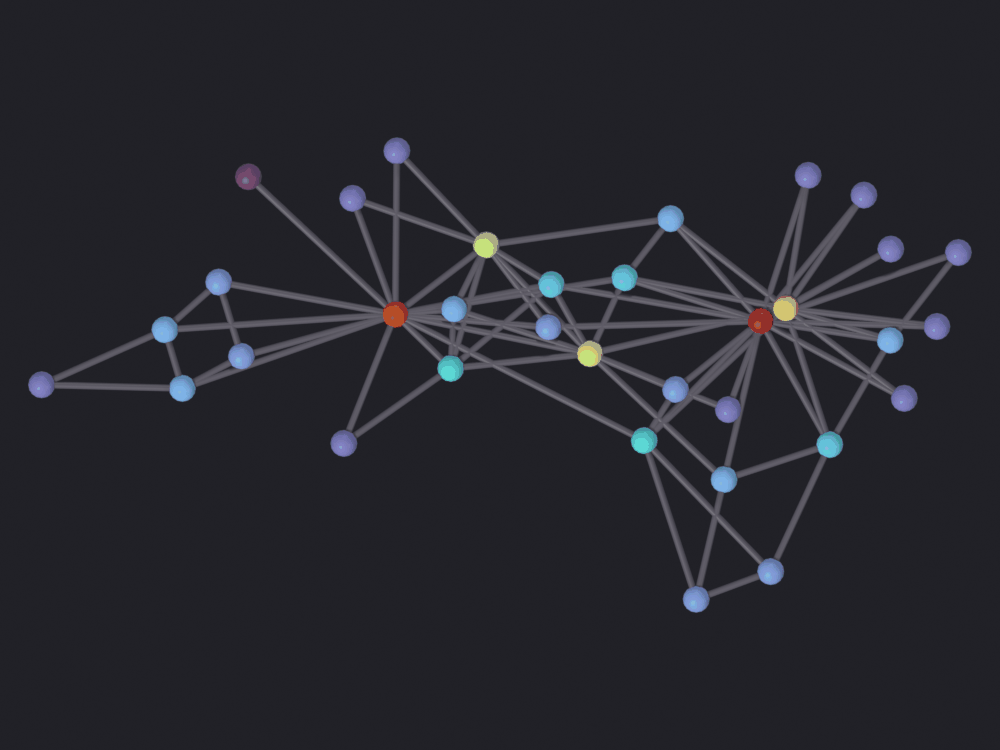

True

In [9]:
for fraction in (0.35, 0.22):
    path = nb.render(
        karate, f"renders/01_abstract/1_karate_nf{fraction}",
        look='ink', color_attribute="degree",
        node_fraction=fraction, verbose=False)
    print(f"node_fraction {fraction}: radius "
          f"{karate['scigraphs_node_size']:.4f} BU, ink {nb.ink(path) * 100:.1f} %")
    nb.check_render(path)

nb.show(nb.out("renders/01_abstract/1_karate_nf0.22.png"))

## 3 · The other format: an adjacency matrix

Notebook 15 had `od_matrix_to_graph()` accept an edge list or a square matrix.
The abstract importer does not: `create_graph` reads a CSV of rows and
`load_graph_from_file` (`SciGraphs/core/data_io/importer.py:105`) takes two
column indices out of it. There is no `matrix_type` on this path, and a square
matrix would be read as an edge list between its first two columns. Converting
by hand rather than with `nx.from_numpy_array` keeps the mapping from row
index back to node identifier in view.

In [10]:
small_world = GRAPHS["small_world"]
labels = sorted(small_world.nodes())
A = nx.to_numpy_array(small_world, nodelist=labels)

upper_i, upper_j = np.triu_indices_from(A, k=1)
nonzero = A[upper_i, upper_j] > 0
matrix_edges = pd.DataFrame({
                            "source": [labels[i] for i in upper_i[nonzero]],
                            "target": [labels[j] for j in upper_j[nonzero]],
})
matrix_csv = OUT / "small_world_from_matrix.csv"
matrix_edges.to_csv(matrix_csv, index=False)

print(f"matrix {A.shape}, {int(A.sum() / 2)} undirected non-zero cells")
print(f"edge list written from it: {len(matrix_edges)} rows")

check("the matrix and the edge list describe the same graph",
      {frozenset(e) for e in matrix_edges.itertuples(index=False, name=None)}
      == {frozenset(e) for e in small_world.edges()},
      "the round trip through a dense matrix is lossless for an "
      "unweighted, undirected graph")

matrix (240, 240), 720 undirected non-zero cells
edge list written from it: 720 rows
[PASS] the matrix and the edge list describe the same graph — the round trip through a dense matrix is lossless for an unweighted, undirected graph


True

Two asymmetries, and why the edge list is the native format:

* A dense matrix costs *n*² whatever the graph is. The small-world graph is
  240 × 240 = 57,600 cells for 720 edges, 1.2 % occupancy. At 10,000 nodes it
  is 800 MB against a few megabytes of edge list.
* The matrix *can* say something the edge list cannot: a row and column of
  zeros is an isolated node. Section 6 is where that matters.

In [11]:
density = small_world.number_of_edges() / (A.shape[0] * (A.shape[0] - 1) / 2)
print(f"occupancy of the dense matrix: {density * 100:.2f} %")
print(f"dense at 10,000 nodes        : {10_000 ** 2 * 8 / 1e6:.0f} MB of float64")

occupancy of the dense matrix: 2.51 %
dense at 10,000 nodes        : 800 MB of float64


## 4 · Attributes are the currency

Everything downstream reads mesh attributes: figure color, sizes in a
Geometry Nodes tree, layout weighting, every measure notebooks 03 to 05
compute. So the question about an import route is whether the numbers
survive. Three routes, none alike.

**Route 1: extra columns in the edge CSV.** Any numeric column that is not
source or target is imported twice: onto the edges as `edge_<column>`, and
onto the nodes as five aggregates,
`vertex_<column>_{sum,mean,min,max,count}`
(`SciGraphs/core/mesh/geometry.py:513` and `:537`). The prefix is `vertex_`,
not the `node_` the geospatial importer uses, so notebooks 17 to 19 cannot
assume one convention.

The small-world graph's interesting quantity is an edge property: how far
apart two nodes are **on the original ring**. A lattice edge joins near
neighbors, a rewired shortcut joins the far side.

In [12]:
N_RING = small_world.number_of_nodes()


def ring_gap(u, v):
    """Distance between two node indices around the ring they started on."""
    d = abs(int(u) - int(v))
    return min(d, N_RING - d)


sw_csv = write_edge_csv(small_world, OUT / "small_world_edges.csv",
                        edge_columns=[("ring_gap", ring_gap)])
print(pathlib.Path(sw_csv).read_text().splitlines()[:4])

sw = import_edge_list(sw_csv, "SmallWorld")

print()
print("attributes after import:")
for name, domain, dtype in sg.graphs.attributes(sw):
    if not name.startswith("."):
        print(f"  {name:<28} {domain:<7} {dtype}")

['source,target,ring_gap', '0,1,1', '0,239,1', '0,238,2']
Info: Loaded 3 columns
Loading graph from notebooks/out/15_abstract/small_world_edges.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 240, Edges: 720

Creating graph object with 240 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  720 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target', 'ring_gap']
DataFrame shape: (720, 3)
Source column: source, Target column: target
Number of mesh vertices: 240
Number of mesh edges: 720
Selected attributes for import: ['source', 'target', 'ring_gap']
Processing column 'ring_gap': int64
  Created edge attribute 'edge_ring_gap'
  Created vertex attributes for 'ring_gap': sum, mean, min, max, count
Imported 1 attribute columns
  Attributes imported in 0.01s
Total graph creation time: 0.01s

Layout algorithm: SPRING
Graph: 240

> **Defect: the auto-layout wipes every EDGE attribute.**
> `rebuild_edges()` restores the mesh's edges after a layout has moved the
> vertices by deleting every bmesh edge and creating it again
> (`SciGraphs/core/mesh/geometry.py:1227` to `:1248`). `EDGE`-domain custom
> attributes come back allocated and zeroed. The import operator calls it on
> every import that applies a layout, the default
> (`SciGraphs/ui/operators/scigraphs/data_operators.py:41`), as does every one
> of the seven layout operators
> (`SciGraphs/ui/operators/scigraphs/layout_operators.py:322`, `:397`, `:483`,
> `:589`, `:639`). The give-away: the *same column* survives on the other
> domain, since `rebuild_edges` leaves vertices alone, so the
> `vertex_ring_gap_*` aggregates are intact. An edge-valued figure comes out
> uniformly colored and nothing raises.

In [13]:
def read_attribute(obj, name):
    attr = obj.data.attributes[name]
    count = len(obj.data.edges) if attr.domain == 'EDGE' else len(obj.data.vertices)
    values = np.empty(count, dtype=np.float64)
    attr.data.foreach_get("value", values)
    return values


from_operator = read_attribute(sw, "edge_ring_gap")
aggregate = read_attribute(sw, "vertex_ring_gap_max")

print(f"edge_ring_gap        min {from_operator.min():g}  max {from_operator.max():g}")
print(f"vertex_ring_gap_max  min {aggregate.min():g}  max {aggregate.max():g}")

check("the EDGE attribute was zeroed by the layout",
      np.all(from_operator == 0),
      "same CSV column, same import, different domain")
check("the POINT aggregates of the same column survived",
      aggregate.max() > 0)

edge_ring_gap        min 0  max 0
vertex_ring_gap_max  min 3  max 119
[PASS] the EDGE attribute was zeroed by the layout — same CSV column, same import, different domain
[PASS] the POINT aggregates of the same column survived


True

**Route 2: write the attribute yourself, after the layout.** The
general answer to "I computed something in Python and want to see it". The
care goes into the join from mesh index back to node identifier, through
`nodes_data`. Keying on the identifier pair rather than on edge order means
the result does not depend on the importer preserving the CSV's ordering,
which it happens to do, but nothing says so.

In [14]:
def set_edge_attribute(obj, name, values_by_pair):
    """Write a per-edge float, keyed by the unordered pair of node identifiers."""
    names = node_names(obj)
    pairs = edge_pairs(obj)
    values = np.zeros(len(pairs), dtype=np.float32)
    unmatched = 0
    for index, (a, b) in enumerate(pairs):
        key = (names[a], names[b])
        if key in values_by_pair:
            values[index] = values_by_pair[key]
        elif (key[1], key[0]) in values_by_pair:
            values[index] = values_by_pair[(key[1], key[0])]
        else:
            unmatched += 1
    mesh = obj.data
    if name in mesh.attributes:
        mesh.attributes.remove(mesh.attributes[name])
    attr = mesh.attributes.new(name=name, type='FLOAT', domain='EDGE')
    attr.data.foreach_set("value", values.tolist())
    return values, unmatched


gaps, unmatched = set_edge_attribute(
    sw, "edge_ring_gap",
    {(str(u), str(v)): float(ring_gap(u, v)) for u, v in small_world.edges()})

print(f"rewritten: {len(gaps)} edges, {unmatched} unmatched, "
      f"range {gaps.min():g} to {gaps.max():g}")
print(f"shortcuts (gap > {small_world.degree(0) // 2}): "
      f"{int((gaps > small_world.degree(0) // 2).sum())}")

check("every mesh edge found its pair in the graph", unmatched == 0)
check("the edge attribute now carries the measurement", gaps.max() > 0)

rewritten: 720 edges, 0 unmatched, range 1 to 119
shortcuts (gap > 3): 52
[PASS] every mesh edge found its pair in the graph
[PASS] the edge attribute now carries the measurement


True

**The color scale for a bimodal quantity.** `ring_gap` is not
skewed, it is bimodal: lattice edges at 1 to 3, rewired ones scattered up to
half the ring. A linear ramp gives 90 % of the edges the bottom 2 % of the
scale, and no percentile clip fixes it: clipping moves the top of the ramp and
the problem is at the bottom. `color_norm='LOG'` separates two clusters an
order of magnitude apart.

(`vmin=`/`vmax=` are silently ineffective: `scigraphs.color_set_attribute`
calls `update_property_range()` before applying anything
(`SciGraphs/ui/coloring/operators.py:374`) and overwrites both.
`clip_low_pct`/`clip_high_pct` work.)

In [15]:
linear_share = (np.percentile(gaps, 90) - gaps.min()) / (gaps.max() - gaps.min())
log_share = (np.log(np.percentile(gaps, 90)) - np.log(gaps.min())) / (
    np.log(gaps.max()) - np.log(gaps.min()))
print(f"90 % of the edges fall inside the bottom "
      f"{linear_share * 100:.0f} % of a linear ramp, "
      f"{log_share * 100:.0f} % of a logarithmic one")

90 % of the edges fall inside the bottom 2 % of a linear ramp, 23 % of a logarithmic one


The nodes are deliberately small: the measurement is on the
*edges*, and a glyph large enough to be pleasant hides the data. `color_graph`
leaves the node spheres on the same ramp, where they show the average gap of
the edges meeting there.

  Promoted 1 edge attribute(s) to point domain for GN propagation
Info: Geometry Nodes modifier added
Info: Attribute -> edge_ring_gap  ·  edge_ring_gap -> turbo [log]  [1 … 119] on Point


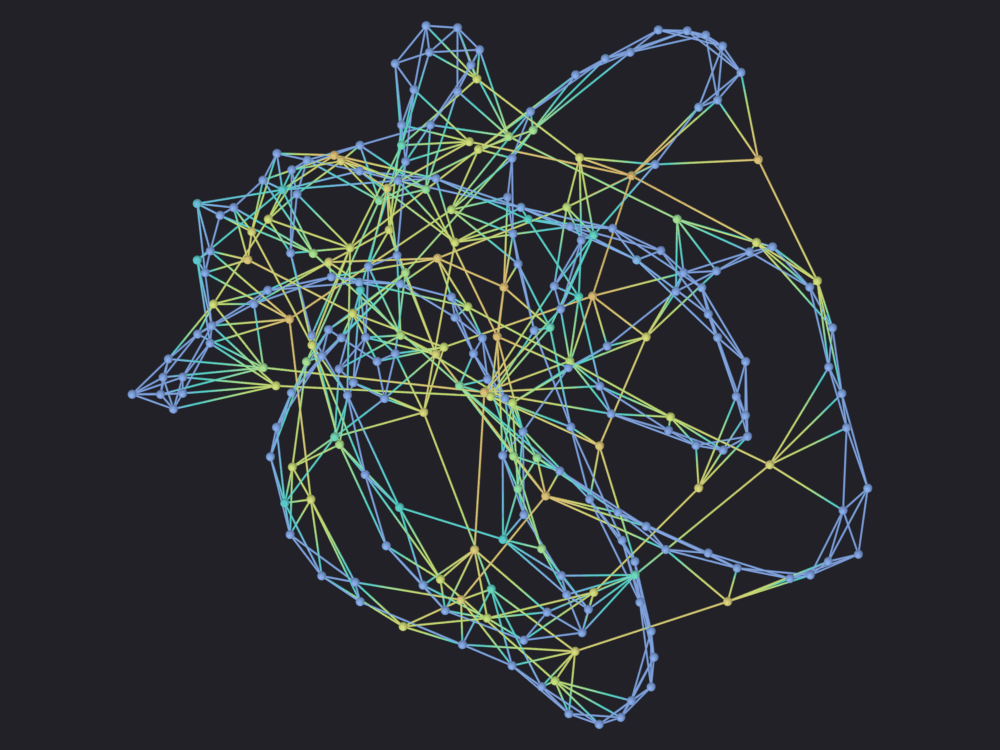

[PASS] 2_small_world_ring_gap.png legible — 15.9% ink (healthy range 0.5–60%)


In [16]:
nb.figure(sw, "renders/01_abstract/2_small_world_ring_gap",
          look='ink', color_attribute="edge_ring_gap",
          color_norm='LOG', node_fraction=0.22)

**Route 3: the `import_node_attributes` operator.** The GUI
route for per-node values computed elsewhere: identifier in the first column,
one value column per attribute. Unlike route 1 it runs *after* the graph
exists, so nothing rebuilds the mesh underneath it; unlike route 2 it is on
the panel. Third naming convention on this page: with a header row the
attribute takes the column's name **verbatim**, no prefix.

In [17]:
karate_graph = GRAPHS["karate"]
attribute_file = OUT / "karate_node_attributes.tsv"
pd.DataFrame({
             "node": list(karate_graph.nodes()),
             "betweenness": [round(v, 6) for v in
             nx.betweenness_centrality(karate_graph).values()],
             "clustering": [round(v, 6) for v in nx.clustering(karate_graph).values()],
}).to_csv(attribute_file, sep="\t", index=False)

props = bpy.context.scene.scigraphs
props.node_attr_filepath = str(attribute_file)
props.node_attr_delimiter = "\t"
props.node_attr_has_header = True

sg.graphs.activate(karate)
print("import_node_attributes ->", bpy.ops.scigraphs.import_node_attributes())
print("names on the mesh now:",
      [n for n, _, _ in sg.graphs.attributes(karate) if not n.startswith(".")])

betweenness = read_attribute(karate, "betweenness")
expected = np.array([nx.betweenness_centrality(karate_graph)[int(n)]
                    for n in node_names(karate)])
check("the values landed on the right vertices",
      np.allclose(betweenness, expected, atol=1e-5),
      f"max disagreement {np.abs(betweenness - expected).max():.2e}")

  Created POINT attribute 'betweenness' (34 nodes matched)
  Created POINT attribute 'clustering' (34 nodes matched)
Imported 2 node attribute(s), 34 nodes matched out of 34
  Rebuilt simple GN tree (attribute stripping updated)
Info: Imported 2 attribute(s): 34/34 nodes matched
import_node_attributes -> {'FINISHED'}
names on the mesh now: ['node_id', 'position', 'degree', 'degree_color', 'betweenness', 'clustering']
[PASS] the values landed on the right vertices — max disagreement 4.88e-07


True

> **Worth knowing:** a node in the graph but absent from the file
> is given `float('nan')`, deliberately, so missing data is distinguishable
> from zero (`SciGraphs/core/mesh/geometry.py:658`). The coloring pipeline
> ignores non-finite samples, so a partial file does not distort the ramp, but
> the nodes it missed take the fallback color and nothing says how many
> except the operator's own report. Check the count.

In [18]:
missing = int(np.isnan(betweenness).sum())
print(f"nodes with no value: {missing} of {len(betweenness)}")
check("every node matched a row", missing == 0)

nodes with no value: 0 of 34
[PASS] every node matched a row


True

## 5 · What is different without coordinates

With `auto_layout_on_import` off, `create_graph` still produces a valid
SciGraphs object, right node count, right edge count, every attribute in
place, and puts every vertex at a **seeded random point in a 5-unit cube**
(`SciGraphs/core/mesh/geometry.py:297`). Same karate graph as figure 1.

Info: Loaded 2 columns
Loading graph from notebooks/out/15_abstract/karate_edges.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 34, Edges: 78

Creating graph object with 34 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  78 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target']
DataFrame shape: (78, 2)
Source column: source, Target column: target
Number of mesh vertices: 34
Number of mesh edges: 78
Selected attributes for import: ['source', 'target']
Imported 0 attribute columns
  Attributes imported in 0.00s
Total graph creation time: 0.00s
Info: Graph created: 34 nodes, 78 edges
positions span [4.66 4.98 4.72] Blender units: a cube, not a drawing
[PASS] the topology is identical to figure 1
Info: Geometry Nodes modifier added
Info: Attribute -> degree  ·  degree -> turbo [log]  [1 … 17] on Point


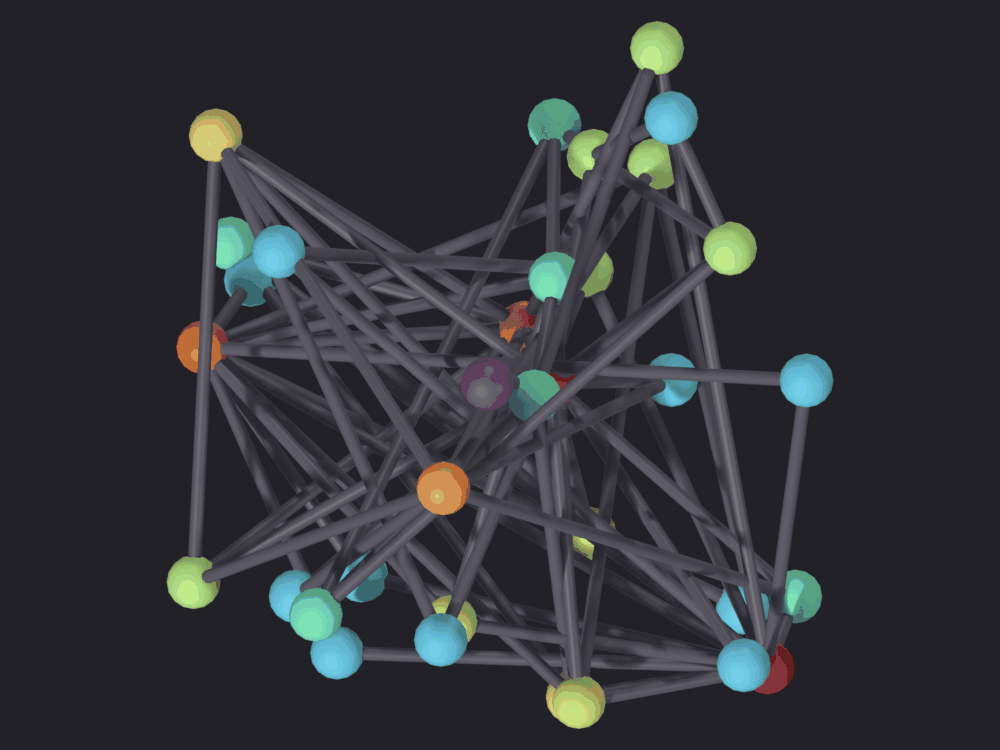

[PASS] 3_karate_no_layout.png legible — 29.8% ink (healthy range 0.5–60%)


In [19]:
raw = import_edge_list(karate_csv, "Karate_NoLayout", auto_layout=False)
set_point_attribute(raw, "degree", [degree[int(n)] for n in node_names(raw)])

extent = positions(raw).max(axis=0) - positions(raw).min(axis=0)
print(f"positions span {extent.round(2)} Blender units: a cube, not a drawing")
check("the topology is identical to figure 1",
      {frozenset((int(node_names(raw)[a]), int(node_names(raw)[b])))
      for a, b in edge_pairs(raw)} == original)

nb.figure(raw, "renders/01_abstract/3_karate_no_layout",
          look='ink', color_attribute="degree", node_fraction=0.22)

The two figures are the same object in every sense a graph
theorist would recognize, and only one can be read. That gap is the subject of
**16 · Layouts**: which algorithm, in how many dimensions, with what seed, and
what the distances are allowed to mean, a question the geospatial notebooks
never have to ask. They mean nothing here; the only honest reading of a force
layout is topological: *this* group is more densely wired to itself than to
the rest.

The default `FORCEATLAS2` is genuinely three-dimensional and the overhead
camera throws one axis away, which on the karate graph is not a rounding
error. Hence the planar `SPRING`, the one under which the picture and the
computation agree.

In [20]:
flat = import_edge_list(karate_csv, "Karate_FA2", layout='FORCEATLAS2')
span = positions(flat).max(axis=0) - positions(flat).min(axis=0)
print(f"FORCEATLAS2 span x={span[0]:.2f} y={span[1]:.2f} z={span[2]:.2f}")
print(f"the axis the camera discards is {span[2] / max(span[0], span[1]) * 100:.0f} % "
      f"of the longest one it keeps")

span_spring = positions(karate).max(axis=0) - positions(karate).min(axis=0)
check("the layout used for these figures is planar", span_spring[2] == 0.0,
      f"SPRING span z={span_spring[2]:.3f}")

bpy.data.objects.remove(flat, do_unlink=True)
raw.hide_render = True

Info: Loaded 2 columns
Loading graph from notebooks/out/15_abstract/karate_edges.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 34, Edges: 78

Creating graph object with 34 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  78 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target']
DataFrame shape: (78, 2)
Source column: source, Target column: target
Number of mesh vertices: 34
Number of mesh edges: 78
Selected attributes for import: ['source', 'target']
Imported 0 attribute columns
  Attributes imported in 0.00s
Total graph creation time: 0.00s
Computing ForceAtlas2 (3D, networkx) for 34 nodes...
  ForceAtlas2 completed in 0.01s

Layout algorithm: FORCEATLAS2
Fallback: using SPRING (2D fallback) instead
   Reason: FORCEATLAS2 library not available
Graph: 34 nodes, 78 edges
Parameters:
  - algorithm: FORCEATLAS2
  - it

## 6 · Two degree distributions, and one color scale that lies

The Erdős-Rényi and Barabási-Albert graphs have almost the same size and
density, and completely different degree distributions. That difference is
invisible in the topology checks and decides how a figure has to be colored.

In [21]:
summary = []
for name in ("random", "scale_free"):
    d = np.array([v for _, v in GRAPHS[name].degree()], dtype=float)
    summary.append({"graph": name, "n": len(d), "median": np.median(d),
                   "p98": round(float(np.percentile(d, 98)), 1),
                   "max": d.max(), "max/median": round(d.max() / np.median(d), 1)})
print(pd.DataFrame(summary).to_string(index=False))

     graph   n  median  p98  max  max/median
    random 300     6.0 11.0 19.0         3.2
scale_free 300     3.0 14.0 55.0        18.3


### The random graph

`erdos_renyi_graph(300, 0.02)` has an isolated node, and **an edge list cannot
express one**: a node with no edges leaves no trace in a file of edge rows, so
299 of the 300 arrive. That is the format, not an add-on defect, and the one
case where the adjacency matrix of section 3 says more.

In [22]:
random_graph = GRAPHS["random"]
random_csv = write_edge_csv(random_graph, OUT / "random_edges.csv")
random_obj = import_edge_list(random_csv, "Random")

isolated = list(nx.isolates(random_graph))
print(f"isolated nodes in the generator: {len(isolated)} {isolated}")
print(f"nodes in the CSV               : {random_obj['num_nodes']} "
      f"of {random_graph.number_of_nodes()}")

check("the isolated node did not survive the edge list",
      random_obj["num_nodes"] == random_graph.number_of_nodes() - len(isolated),
      "add it back through the adjacency route, or accept the loss "
      "and say so")

set_point_attribute(random_obj, "degree",
                    [float(random_graph.degree(int(n)))
                    for n in node_names(random_obj)])

Info: Loaded 2 columns
Loading graph from notebooks/out/15_abstract/random_edges.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 299, Edges: 889

Creating graph object with 299 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  889 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target']
DataFrame shape: (889, 2)
Source column: source, Target column: target
Number of mesh vertices: 299
Number of mesh edges: 889
Selected attributes for import: ['source', 'target']
Imported 0 attribute columns
  Attributes imported in 0.00s
Total graph creation time: 0.00s

Layout algorithm: SPRING
Graph: 299 nodes, 889 edges
Parameters:
  - algorithm: SPRING
  - iterations: 50
  - scale: 5.0000
  - num_nodes: 299
  - num_edges: 889
Execution time: 0.103s
Status: success

Info: Auto-layout applied: SPRING
Info: Graph created: 299 nodes, 88

'degree'

Degrees here run from 1 to about three times the median. The
whole ramp is doing work at full range, so there is nothing to clip.

Info: Geometry Nodes modifier added
Info: Attribute -> degree  ·  degree -> turbo [log]  [1 … 19] on Point


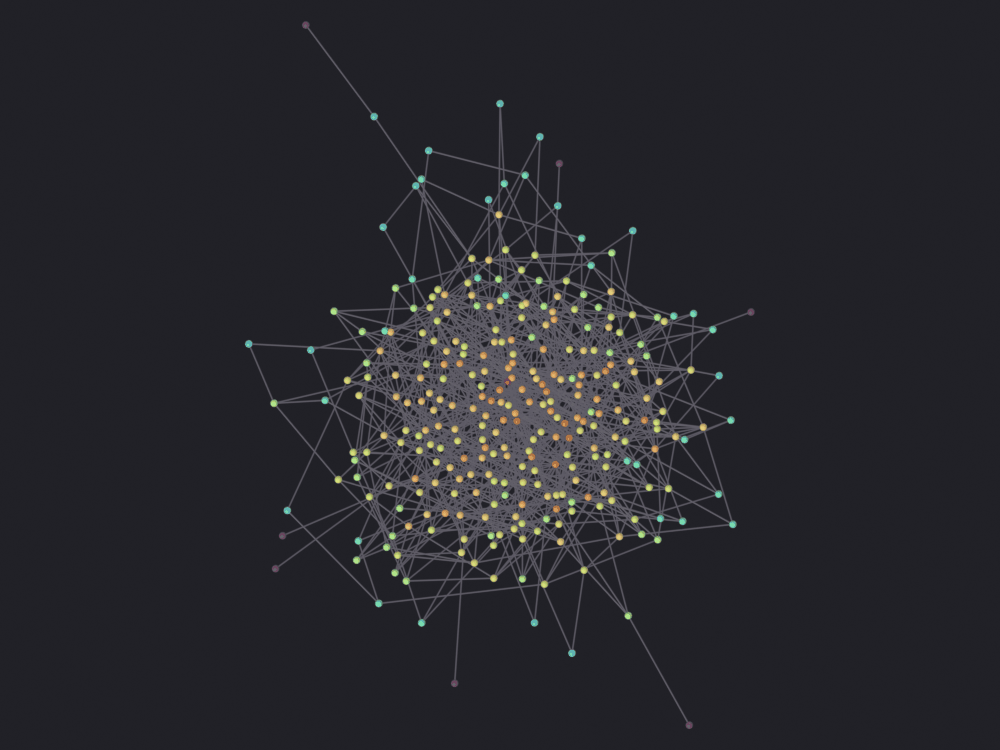

[PASS] 4_random_degree.png legible — 11.9% ink (healthy range 0.5–60%)


In [23]:
nb.figure(random_obj, "renders/01_abstract/4_random_degree",
          look='ink', color_attribute="degree", node_fraction=0.28)
random_obj.hide_render = True

### The scale-free graph, twice

Preferential attachment produces a handful of hubs with a degree many times
the median. Mapped linearly they take the top of the scale and everything else
is compressed into the bottom stop: a degree of 2 is indistinguishable from a
degree of 10. The second render clips the top 2 %.

In [24]:
scale_free = GRAPHS["scale_free"]
sf_csv = write_edge_csv(scale_free, OUT / "scale_free_edges.csv")
sf = import_edge_list(sf_csv, "ScaleFree")
sf_degree = np.array([float(scale_free.degree(int(n))) for n in node_names(sf)])
set_point_attribute(sf, "degree", sf_degree)

cut = np.percentile(sf_degree, 98)
above = int((sf_degree > cut).sum())
print(f"degrees: median {np.median(sf_degree):g}, 98th percentile {cut:.1f}, "
      f"max {sf_degree.max():g}")
print(f"{len(sf_degree) - above} of {len(sf_degree)} nodes sit below the 98th "
      f"percentile, i.e. inside the bottom {cut / sf_degree.max() * 100:.0f} % "
      f"of a linear ramp")
print(f"the remaining {above} nodes have the other "
      f"{100 - cut / sf_degree.max() * 100:.0f} % to themselves")

Info: Loaded 2 columns
Loading graph from notebooks/out/15_abstract/scale_free_edges.csv...
  CSV read in 0.00s
  Edges extracted in 0.00s
  Nodes extracted in 0.00s
Total load time: 0.00s
  Nodes: 300, Edges: 596

Creating graph object with 300 nodes...
  Random positions generated in 0.00s (seed=1426602425)
  Vertices created in 0.00s
  596 edges created in 0.00s
  Mesh conversion in 0.00s
  Object created in 0.00s
DataFrame columns: ['source', 'target']
DataFrame shape: (596, 2)
Source column: source, Target column: target
Number of mesh vertices: 300
Number of mesh edges: 596
Selected attributes for import: ['source', 'target']
Imported 0 attribute columns
  Attributes imported in 0.00s
Total graph creation time: 0.00s

Layout algorithm: SPRING
Graph: 300 nodes, 596 edges
Parameters:
  - algorithm: SPRING
  - iterations: 50
  - scale: 5.0000
  - num_nodes: 300
  - num_edges: 596
Execution time: 0.106s
Status: success

Info: Auto-layout applied: SPRING
Info: Graph created: 300 nodes

Info: Geometry Nodes modifier added
Info: Attribute -> degree  ·  degree -> turbo [log]  [2 … 55] on Point
unclipped, the ramp maps (2.0, 55.0)


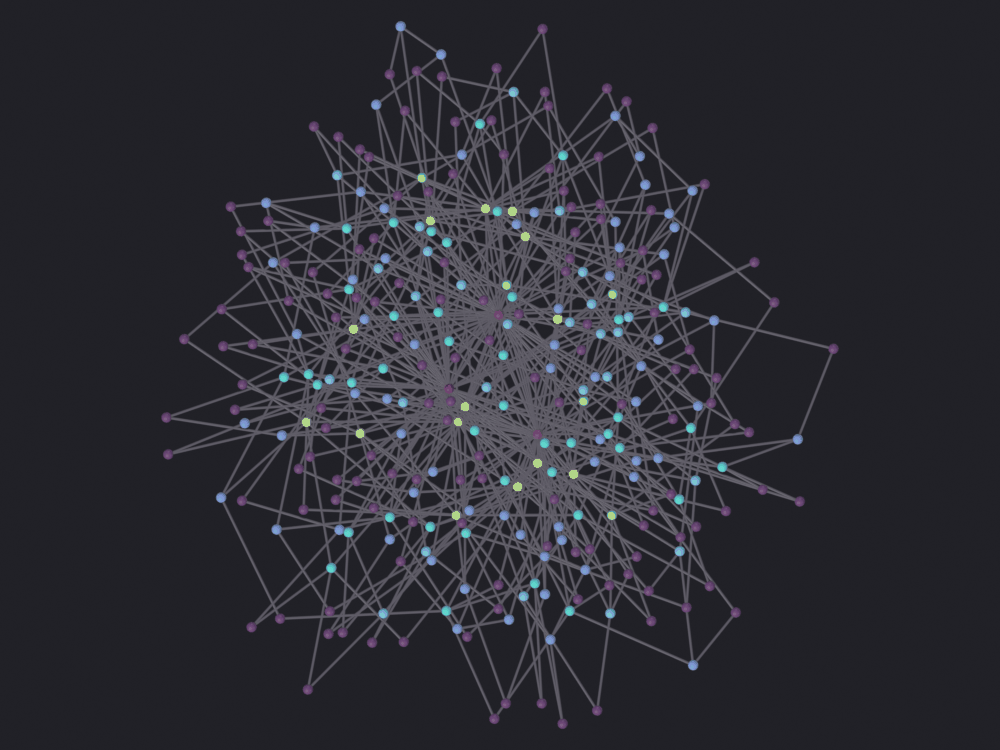

[PASS] 5_scale_free_linear.png legible — 21.3% ink (healthy range 0.5–60%)


True

In [25]:
path = nb.render(sf, "renders/01_abstract/5_scale_free_linear",
                 look='ink', color_attribute="degree",
                 node_fraction=0.28, verbose=False)
print("unclipped, the ramp maps", sg.render.color_range(sf))
nb.show(path)
nb.check_render(path)

Info: Geometry Nodes modifier added
Info: Attribute -> degree  ·  degree -> turbo [log]  [2 … 14.02] on Point
clipped at 98 %, the ramp maps (2.0, 14.020000457763672)


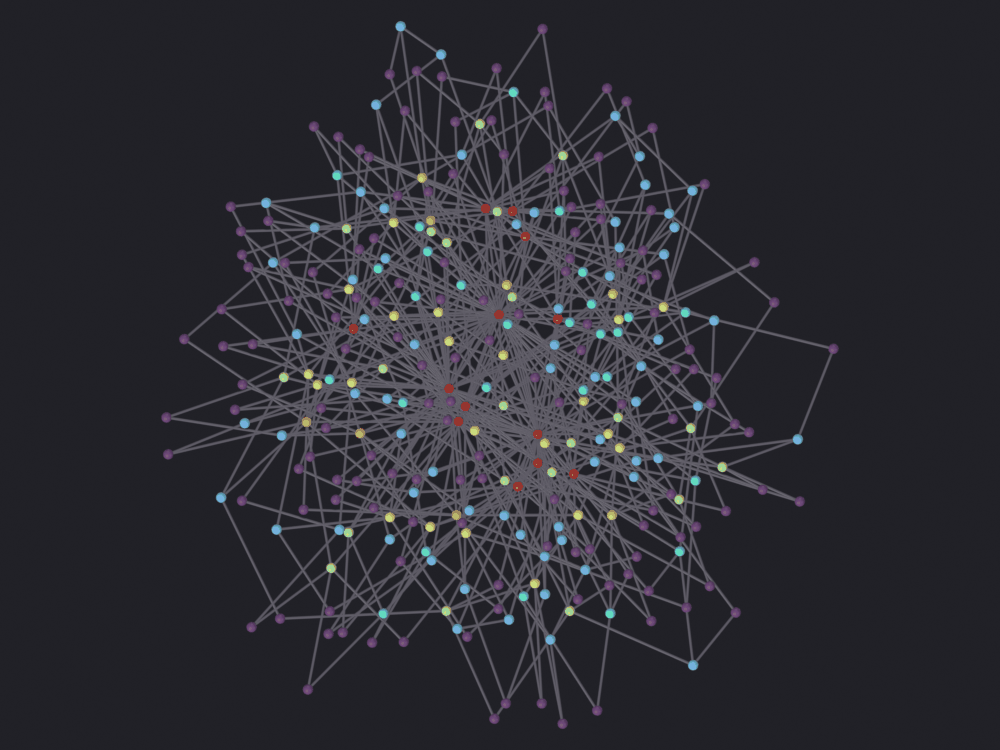

[PASS] 6_scale_free_clipped.png legible — 21.3% ink (healthy range 0.5–60%)


True

In [26]:
path = nb.render(sf, "renders/01_abstract/6_scale_free_clipped",
                 look='ink', color_attribute="degree",
                 clip_high_pct=98, node_fraction=0.28,
                 verbose=False)
print("clipped at 98 %, the ramp maps", sg.render.color_range(sf))
nb.show(path)
nb.check_render(path)

The two frames have the same geometry, the same node size and
the same ink to within a tenth of a percent. `check_render` cannot tell them
apart and neither can any other automatic test here. Only one can be read,
which is the argument for looking at every figure.

In [27]:
print(f"unclipped ink {nb.ink(nb.out('renders/01_abstract/5_scale_free_linear.png')) * 100:.1f} %")
print(f"clipped   ink {nb.ink(nb.out('renders/01_abstract/6_scale_free_clipped.png')) * 100:.1f} %")
sf.hide_render = True

unclipped ink 21.3 %
clipped   ink 21.3 %


## 7 · A matrix somebody else made: SuiteSparse

Everything so far was generated on this machine. The SuiteSparse Matrix
Collection (<https://sparse.tamu.edu>) is about 3,000 real sparse matrices
from structural engineering, circuit simulation, optimization and web crawls;
`scigraphs.download_suitesparse` turns one into a graph.

**`RUN_SUITESPARSE`** is off by default: the only cell that reaches the
network. On, it costs

* one `GET https://sparse.tamu.edu/MM/<Group>/<Name>.tar.gz`
  (`SciGraphs/core/data_io/suitesparse_importer.py:65`), 120 s timeout;
* **no caching**: the importer downloads into memory, extracts the `.mtx` and
  drops the archive, so every run pays the transfer again;
* the default `Grund/bayer09` is one of the small ones; the collection goes up
  to hundreds of millions of non-zeros, with no warning before fetching one.

`scigraphs.browse_suitesparse` is not an API: it is
`webbrowser.open("https://sparse.tamu.edu")` and nothing else
(`SciGraphs/ui/operators/scigraphs/suitesparse_operators.py:66`), so the
catalog cannot be searched from the add-on; pick the identifier in a browser
and paste it in. Under `blender -b` it would try to spawn a browser, the
second reason for the switch.

In [28]:
RUN_SUITESPARSE = False

SUITESPARSE_ID = "Grund/bayer09"

Two settings decide what graph comes out of a matrix that is not
necessarily square or symmetric:

* `suitesparse_mode='BIPARTITE'` (default) makes a node per row and per
  column, named `R<i>` and `C<j>`, with an edge per non-zero. It preserves the
  matrix exactly and lays out long and thin.
* `suitesparse_mode='SYMMETRIC'` reads the matrix as an adjacency matrix,
  symmetrizing it as A + Aᵀ. Only defensible when rows and columns index the
  same thing.
* `suitesparse_giant_only=True` keeps the largest connected component. Real
  solver matrices are full of tiny detached fragments, and a layout spends
  most of its frame separating them from the part you wanted.

A few matrices ship a `<name>_coord.mtx` alongside, and the importer then uses
those coordinates as the initial positions (`suitesparse_importer.py:246`):
the one case here where an abstract graph arrives with a geometry of its own.

In [29]:
if RUN_SUITESPARSE:
    props = bpy.context.scene.scigraphs
    props.suitesparse_id = SUITESPARSE_ID
    props.suitesparse_mode = 'BIPARTITE'
    props.suitesparse_giant_only = True
    props.auto_layout_on_import = True
    props.layout_algorithm = 'SPRING'
    props.layout_scale = 5.0
    np.random.seed(LAYOUT_SEED)

    result = bpy.ops.scigraphs.download_suitesparse()
    print("download_suitesparse ->", result)
    print("status:", props.suitesparse_status)

    if 'FINISHED' in result:
        matrix_obj = bpy.context.active_object
        matrix_obj.name = "SuiteSparse"
        set_point_attribute(
            matrix_obj, "degree",
            np.bincount(edge_pairs(matrix_obj).ravel(),
                        minlength=len(matrix_obj.data.vertices)).astype(float))
        nb.figure(matrix_obj, "renders/01_abstract/7_suitesparse",
                  look='ink', color_attribute="degree",
                  clip_high_pct=98, node_fraction=0.28)
else:
    print(f"RUN_SUITESPARSE is off. It would fetch "
          f"https://sparse.tamu.edu/MM/{SUITESPARSE_ID}.tar.gz, "
          f"uncached, on every run.")

RUN_SUITESPARSE is off. It would fetch https://sparse.tamu.edu/MM/Grund/bayer09.tar.gz, uncached, on every run.


## 8 · Saving

The CSVs are what `create_graph` reads, so a saved edge list plus the two
seeds at the top of this notebook rebuilds every figure above.

In [30]:
print("written to", nb.rel(OUT))
for path in sorted(OUT.iterdir()):
    print(f"   {path.name:<34} {path.stat().st_size / 1e3:6.1f} kB")

check("the graphs can be rebuilt from what was saved",
      (OUT / "karate_edges.csv").is_file()
      and (OUT / "scale_free_edges.csv").is_file())

written to notebooks/out/15_abstract
   comma_labels.csv                      0.0 kB
   innocent_column_names.csv             0.2 kB
   karate_edges.csv                      0.4 kB
   karate_node_attributes.tsv            0.6 kB
   random_edges.csv                      6.5 kB
   scale_free_edges.csv                  3.9 kB
   small_world_edges.csv                 6.6 kB
   small_world_from_matrix.csv           5.1 kB
[PASS] the graphs can be rebuilt from what was saved


True

## Rendering

Seven figures, all EEVEE through `sg.render`; notebook 13 explains the render
path. Elsewhere the overhead camera is there so a map can be measured off the
page; here nothing can be, and the reason to keep it is that it is the only
projection under which the *same* layout gives the *same* picture twice, which
comparing figures 5 and 6, or 1 and 3, depends on. Notebook 02 examines the
trade properly.

> The Vulkan warning applies here as everywhere: on Blender's **Vulkan**
> backend, the default on Linux, `gpu.state.point_size_set` does nothing for
> the add-on's shaders, so `POINT` and `DISK` nodes in the interactive preview
> come out **1 pixel** wide. Start Blender with `--gpu-backend opengl` for any
> render you intend to look at.

## Summary

Five defects, all in the add-on, with the workaround used here:

| What | Where | Workaround used here |
|---|---|---|
| `density` read as a latitude, so the import silently becomes geospatial | `core/geo/geospatial.py:40`, via `data_operators.py:127` | `use_geospatial = False` after `load_columns` |
| The 2D/3D spring layouts take no seed | `core/mesh/layouts/networkx_layouts.py:8`, `:18` | seed `np.random` before the operator |
| Every layout wipes `EDGE` attributes via `rebuild_edges` | `core/mesh/geometry.py:1227`; called from `data_operators.py:41` and five places in `layout_operators.py` | write edge attributes *after* the layout |
| Node identifiers are a comma-joined string | `core/mesh/geometry.py:383`, `:394` | no commas in node names |
| `create_graph_object` links into `bpy.context.collection` unchecked | `core/mesh/geometry.py:376` | go through the operator, which supplies a context |

Next: **16 · Layouts**, the algorithm that invents the positions.